# VESTA — Exploratory Data Analysis: Comprehensive Fundamental & Corporate Governance Lakehouse (11.7 GB Snapshot)
### Nghiên Cứu Định Lượng Chuyên Sâu Toàn Diện: 439k BCTC (2006-2026), 7.36M Thuyết Minh, 4.2k Cổ Đông, 1.5k Lãnh Đạo, 38.8k Sự Kiện & 4.84M Dòng Tiền Ngoại (F100)

---

**Mục tiêu nghiên cứu tổng thể:**
1. **Kiểm toán Cấu Trúc Toàn Bộ CSDL Snapshot:** Khảo sát toàn cảnh 75 bảng/views (11.7 GB) phân bổ trên 4 schemas (`core`, `staging`, `meta`, `preprocessed`).
2. **Khảo sát Báo Cáo Tài Chính 5 Phân Khúc (`core.fundamentals` - 439,700 bản ghi):** Đánh giá độ phủ 81 quý liên tục (2006-2026) qua Balance Sheet, Income Statement, Cash Flow, Financial Health và 60 Ratios định lượng.
3. **Mô Hình Sức Khỏe Tài Chính & Dự Báo Rủi Ro Phá Sản:** Khảo sát phân bổ điểm chất lượng kế toán Piotroski F-Score (0-9) và mô hình vùng rủi ro vỡ nợ Altman Z-Score qua các chu kỳ khủng hoảng kinh tế (2008, 2011, 2020, 2022).
4. **Cơ Cấu Quản Trị & Bản Đồ Sở Hữu Doanh Nghiệp:** Phân tích 4,268 cổ đông lớn, 1,522 lãnh đạo chủ chốt (CEO/Chủ tịch HĐQT/Ban kiểm soát), và tỷ lệ sở hữu chi phối của Nhà nước (SCIC), Khối ngoại và Doanh nhân sáng lập.
5. **Định Lượng Sự Kiện Doanh Nghiệp & Độ Trễ Cổ Tức (`core.corporate_events` - 38,803 sự kiện):** Khảo sát chính sách chi trả cổ tức tiền mặt vs cổ phiếu, họp ĐHCĐ, và rủi ro thanh khoản qua độ trễ thanh toán cổ tức `payout_delay_days`.
6. **Hành Vi Dòng Tiền Khối Ngoại & Khối Tự Doanh:** Phân tích 4.84 triệu phiên giao dịch mua/bán ròng của khối ngoại (`core.market_foreign_flow_daily`) và 37.7k phiên của tự doanh CTCK (`core.proprietary_flow`).
7. **Thuyết Minh BCTC Bóc Tách Chi Tiết (`core.financial_notes` - 7.36 triệu dòng) & Định Giá P/E, P/B Chỉ Số.**


In [3]:
import os
import sys
import pathlib
import warnings
import duckdb
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Thiết lập thẩm mỹ đồ thị chuẩn định lượng (Modern Quant Aesthetics)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 15

# Ưu tiên kết nối CSDL snapshot an toàn
db_path = "db/vesta_backup.duckdb" if os.path.exists("db/vesta_backup.duckdb") else "db/vesta_snapshot.duckdb"
con = duckdb.connect(db_path, read_only=True)

file_size_mb = round(os.path.getsize(db_path) / (1024 * 1024), 2)
print(f"✅ Đã kết nối thành công kho Snapshot: {db_path}")
print(f"📦 Dung lượng CSDL: {file_size_mb:,} MB ({file_size_mb/1024:.2f} GB)")
print(f"🦆 DuckDB Engine Version: {duckdb.__version__}")


IOException: IO Error: Cannot open file "D:\VESTA\notebooks\fundamentals\db\vesta_snapshot.duckdb": The system cannot find the path specified.


## 1. Kiểm Toán Toàn Diện Cấu Trúc CSDL Snapshot (75 Bảng & Views)
Khảo sát phân bổ bảng theo 4 schemas (`core`, `staging`, `meta`, `preprocessed`) và xếp hạng Top các bảng lưu trữ lớn nhất.


=== THỐNG KÊ BẢNG VÀ VIEWS THEO SCHEMA ===
=== TOP 12 BẢNG CÓ DUNG LƯỢNG DÒNG LỚN NHẤT (CORE SCHEMA) ===


,table_schema,table_type,count
0,core,BASE TABLE,39
1,core,VIEW,4
2,meta,BASE TABLE,5
3,preprocessed,BASE TABLE,4
4,staging,BASE TABLE,23


,tbl,rows
0,financial_notes,7358616
1,market_ohlcv_1m,6808414
2,market_ohlcv_daily,5185989
3,market_foreign_flow_daily,4839720
4,pit_events,658182
5,macro_policy,479037
6,fundamentals,439700
7,market_index_daily,216960
8,corporate_events,38803
9,proprietary_flow,37757


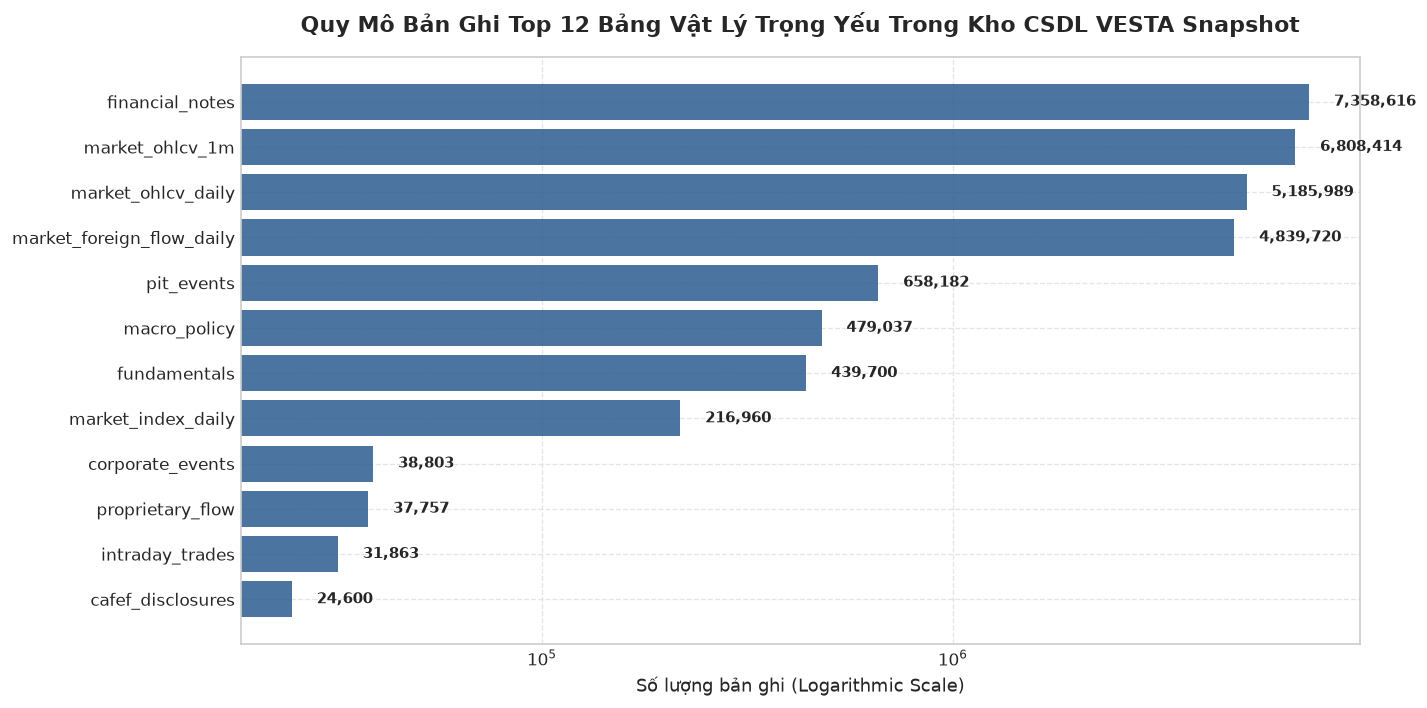

In [ ]:
# Thống kê tổng số bảng và views theo schema
df_tables_all = con.execute("""
    SELECT table_schema, table_type, count(*) as count
    FROM information_schema.tables
    WHERE table_schema NOT IN ('information_schema', 'pg_catalog')
    GROUP BY table_schema, table_type
    ORDER BY table_schema, table_type
""").df()

print("=== THỐNG KÊ BẢNG VÀ VIEWS THEO SCHEMA ===")
display(df_tables_all)

# Xếp hạng Top 12 bảng vật lý lớn nhất trong core schema
top_tables_query = """
    SELECT 'financial_notes' as tbl, count(*) as rows FROM core.financial_notes UNION ALL
    SELECT 'market_ohlcv_1m', count(*) FROM core.market_ohlcv_1m UNION ALL
    SELECT 'market_ohlcv_daily', count(*) FROM core.market_ohlcv_daily UNION ALL
    SELECT 'market_foreign_flow_daily', count(*) FROM core.market_foreign_flow_daily UNION ALL
    SELECT 'pit_events', count(*) FROM core.pit_events UNION ALL
    SELECT 'macro_policy', count(*) FROM core.macro_policy UNION ALL
    SELECT 'fundamentals', count(*) FROM core.fundamentals UNION ALL
    SELECT 'market_index_daily', count(*) FROM core.market_index_daily UNION ALL
    SELECT 'proprietary_flow', count(*) FROM core.proprietary_flow UNION ALL
    SELECT 'corporate_events', count(*) FROM core.corporate_events UNION ALL
    SELECT 'intraday_trades', count(*) FROM core.intraday_trades UNION ALL
    SELECT 'cafef_disclosures', count(*) FROM core.cafef_disclosures
    ORDER BY rows DESC
"""
df_top_tables = con.execute(top_tables_query).df()

print("=== TOP 12 BẢNG CÓ DUNG LƯỢNG DÒNG LỚN NHẤT (CORE SCHEMA) ===")
display(df_top_tables)

# Vẽ biểu đồ ngang cột (Log-scale)
fig, ax = plt.subplots(figsize=(12, 6))
y = np.arange(len(df_top_tables))

bars = ax.barh(y, df_top_tables['rows'], color='#2b5c8f', alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(df_top_tables['tbl'])
ax.invert_yaxis()
ax.set_xscale('log')
ax.set_xlabel('Số lượng bản ghi (Logarithmic Scale)')
ax.set_title('Quy Mô Bản Ghi Top 12 Bảng Vật Lý Trọng Yếu Trong Kho CSDL VESTA Snapshot', fontweight='bold', pad=15)
ax.grid(True, linestyle='--', alpha=0.5)

# Thêm nhãn số lượng dòng
for i, v in enumerate(df_top_tables['rows']):
    ax.text(v * 1.15, i, f"{v:,}", va='center', fontsize=9, fontweight='semibold')

plt.tight_layout()
plt.show()


## 2. Khảo Sát Báo Cáo Tài Chính 5 Phân Khúc (`core.fundamentals` - 439,700 bản ghi)
Kiểm toán chuyên sâu 5 phân hệ báo cáo tài chính: Bảng cân đối kế toán (`balance_sheet`), Báo cáo kết quả kinh doanh (`income_statement`), Báo cáo lưu chuyển tiền tệ (`cash_flow`), Chỉ số tài chính định lượng (`ratio`), và Sức khỏe tài chính (`financial_health`) trải dài suốt 81 quý (2006 – 2026).


=== KIỂM TOÁN 5 PHÂN KHÚC BÁO CÁO TÀI CHÍNH ===


,report_type,total_records,covered_symbols,earliest_period,latest_period,pct_total
0,income_statement,105642,1464,202-03-31,2026-12-31,24.03
1,balance_sheet,103050,1497,202-03-31,2026-12-31,23.44
2,cash_flow,102061,1459,202-03-31,2026-12-31,23.21
3,ratio,70025,1736,2-12-31,2026-12-31,15.93
4,financial_health,58922,1302,202-03-31,2026-12-31,13.40


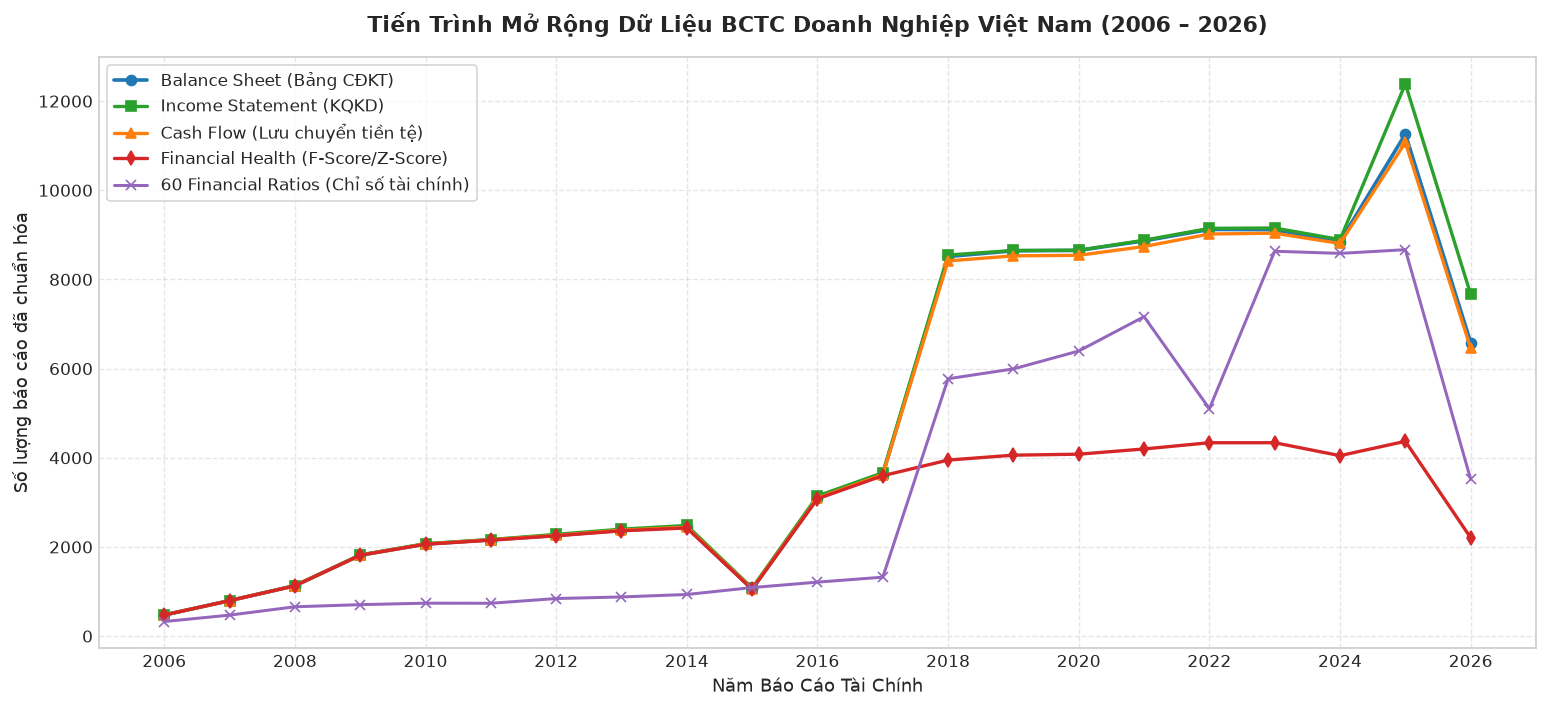

In [ ]:
# Thống kê phân bổ 5 loại báo cáo tài chính
df_fun_stats = con.execute("""
    SELECT 
        report_type,
        count(*) as total_records,
        count(DISTINCT symbol) as covered_symbols,
        min(period_end) as earliest_period,
        max(period_end) as latest_period,
        round(count(*) * 100.0 / sum(count(*)) over(), 2) as pct_total
    FROM core.fundamentals
    GROUP BY report_type
    ORDER BY total_records DESC
""").df()

print("=== KIỂM TOÁN 5 PHÂN KHÚC BÁO CÁO TÀI CHÍNH ===")
display(df_fun_stats)

# Thống kê xu hướng số lượng doanh nghiệp nộp BCTC theo từng năm (2006 - 2026)
df_fun_yearly = con.execute("""
    SELECT 
        year(period_end) as report_year,
        count(CASE WHEN report_type = 'balance_sheet' THEN 1 END) as balance_sheet,
        count(CASE WHEN report_type = 'income_statement' THEN 1 END) as income_statement,
        count(CASE WHEN report_type = 'cash_flow' THEN 1 END) as cash_flow,
        count(CASE WHEN report_type = 'financial_health' THEN 1 END) as financial_health,
        count(CASE WHEN report_type = 'ratio' THEN 1 END) as ratios
    FROM core.fundamentals
    WHERE year(period_end) BETWEEN 2006 AND 2026
    GROUP BY report_year
    ORDER BY report_year
""").df()

# Vẽ biểu đồ đường tiến trình phát triển dữ liệu BCTC qua 20 năm
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(df_fun_yearly['report_year'], df_fun_yearly['balance_sheet'], label='Balance Sheet (Bảng CĐKT)', marker='o', linewidth=2.2, color='#1f77b4')
ax.plot(df_fun_yearly['report_year'], df_fun_yearly['income_statement'], label='Income Statement (KQKD)', marker='s', linewidth=2.0, color='#2ca02c')
ax.plot(df_fun_yearly['report_year'], df_fun_yearly['cash_flow'], label='Cash Flow (Lưu chuyển tiền tệ)', marker='^', linewidth=2.0, color='#ff7f0e')
ax.plot(df_fun_yearly['report_year'], df_fun_yearly['financial_health'], label='Financial Health (F-Score/Z-Score)', marker='d', linewidth=2.0, color='#d62728')
ax.plot(df_fun_yearly['report_year'], df_fun_yearly['ratios'], label='60 Financial Ratios (Chỉ số tài chính)', marker='x', linewidth=1.8, color='#9467bd')

ax.set_xlabel('Năm Báo Cáo Tài Chính')
ax.set_ylabel('Số lượng báo cáo đã chuẩn hóa')
ax.set_title('Tiến Trình Mở Rộng Dữ Liệu BCTC Doanh Nghiệp Việt Nam (2006 – 2026)', fontweight='bold', pad=15)
ax.set_xticks(df_fun_yearly['report_year'][::2])
ax.legend(loc='upper left', frameon=True)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 3. Mô Hình Sức Khỏe Tài Chính & Rủi Ro Phá Sản (Piotroski F-Score & Altman Z-Score)
Phân tích 58,922 bản ghi sức khỏe tài chính định lượng:
1. **Piotroski F-Score (Thang điểm 0 đến 9):** Đánh giá chất lượng kế toán, khả năng sinh lời, đòn bẩy và hiệu quả hoạt động.
2. **Altman Z-Score (Vùng phá sản):** Phân loại rủi ro kiệt quệ tài chính (Distress Zone: $Z < 1.81$, Grey Zone: $1.81 \le Z \le 2.99$, Safe Zone: $Z > 2.99$).


=== PHÂN BỔ THANG ĐIỂM PIOTROSKI F-SCORE (0 - 9 ĐIỂM) ===
f_score
0      902
1     2445
2     7405
3    14877
4    16551
5     9596
6     2791
Name: count, dtype: int64

=== PHÂN BỔ VÙNG RỦI RO PHÁ SẢN ALTMAN Z-SCORE ===
z_zone
Distress    67.19%
Safe        16.96%
Grey        12.40%
Unknown      3.45%
Name: proportion, dtype: object


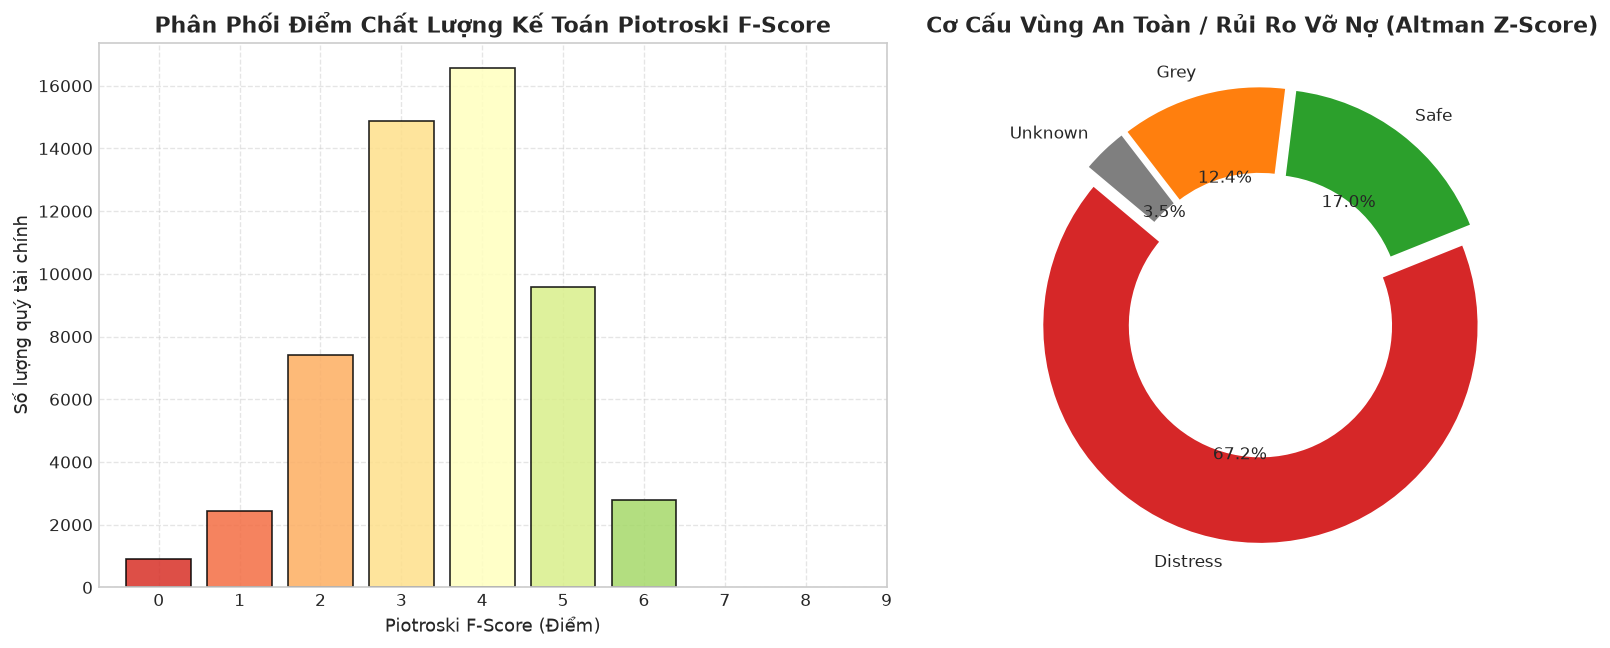

In [ ]:
# Trích xuất và phân tích phân bổ F-Score và Z-Score
df_health_raw = con.execute("""
    SELECT 
        symbol,
        period_end,
        cast(json_extract(data_json, '$.piotroski_f_score') as INTEGER) as f_score,
        cast(json_extract(data_json, '$.altman_z_score') as DOUBLE) as z_score,
        cast(json_extract(data_json, '$.z_score_zone') as VARCHAR) as z_zone
    FROM core.fundamentals
    WHERE report_type = 'financial_health' AND year(period_end) >= 2010
""").df()

# Làm sạch dữ liệu zone
df_health_clean = df_health_raw.dropna(subset=['f_score', 'z_zone'])
df_health_clean['z_zone'] = df_health_clean['z_zone'].str.replace('"', '').str.strip()

print("=== PHÂN BỔ THANG ĐIỂM PIOTROSKI F-SCORE (0 - 9 ĐIỂM) ===")
print(df_health_clean['f_score'].value_counts().sort_index())

print("\n=== PHÂN BỔ VÙNG RỦI RO PHÁ SẢN ALTMAN Z-SCORE ===")
print(df_health_clean['z_zone'].value_counts(normalize=True).apply(lambda x: f"{x*100:.2f}%"))

# Vẽ biểu đồ kép
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# (A) Histogram Piotroski F-Score
f_counts = df_health_clean['f_score'].value_counts().sort_index()
colors_f = ['#d73027', '#f46d43', '#fdae61', '#fee08b', '#ffffbf', '#d9ef8b', '#a6d96a', '#66bd63', '#1a9850', '#006837']
ax1.bar(f_counts.index, f_counts.values, color=colors_f[:len(f_counts)], edgecolor='black', alpha=0.85)
ax1.set_xlabel('Piotroski F-Score (Điểm)')
ax1.set_ylabel('Số lượng quý tài chính')
ax1.set_title('Phân Phối Điểm Chất Lượng Kế Toán Piotroski F-Score', fontweight='bold')
ax1.set_xticks(range(10))
ax1.grid(True, linestyle='--', alpha=0.5)

# (B) Donut chart Altman Z-Score Zone
zone_counts = df_health_clean['z_zone'].value_counts()
colors_z = {'Safe': '#2ca02c', 'Grey': '#ff7f0e', 'Distress': '#d62728'}
ax2.pie(zone_counts.values, labels=zone_counts.index, autopct='%1.1f%%', startangle=140,
        colors=[colors_z.get(k, '#7f7f7f') for k in zone_counts.index], explode=[0.05] * len(zone_counts),
        wedgeprops=dict(width=0.4, edgecolor='w'))
ax2.set_title('Cơ Cấu Vùng An Toàn / Rủi Ro Vỡ Nợ (Altman Z-Score)', fontweight='bold')

plt.tight_layout()
plt.show()


## 4. Cơ Cấu Quản Trị, Cổ Đông Lớn & Loại Hình Doanh Nghiệp
Phân tích bản đồ quản trị doanh nghiệp:
- `core.company_overview`: 1,522 công ty, 32 cột thông tin lãnh đạo (Chủ tịch HĐQT, Tổng Giám đốc, Ban kiểm soát), loại hình DN và kiểm toán viên.
- `core.company_shareholders`: 4,268 cổ đông lớn nắm giữ trên 5% vốn điều lệ.


=== TOP CỔ ĐÔNG LỚN VÀ TỔ CHỨC CHI PHỐI VỐN ===


,shareholder_name,tickers_owned,avg_ownership_pct,max_ownership_pct
0,Lê Phước Vũ,1,1669.00,1669.00
1,CTCP Tập đoàn Sunshine,1,99.96,99.96
2,Tổng Công ty Phát điện 1,4,51.16,99.93
3,Tổng Công ty Đầu tư và Kinh doanh vốn Nhà nước,23,39.86,99.79
4,Tổng Công ty Đầu tư và Kinh doanh vốn nhà nước - Công ty TNHH,1,99.57,99.57
5,UBND Tỉnh Đồng Nai,1,99.54,99.54
6,Bộ Tài chính,8,73.77,99.47
7,Tập đoàn Công nghiệp Than - Khoáng sản Việt Nam,22,62.13,99.27
8,Tập đoàn Điện lực Việt Nam,6,62.02,99.19
9,Tổng Công ty Hàng hải Việt Nam - CTCP,19,56.59,99.05


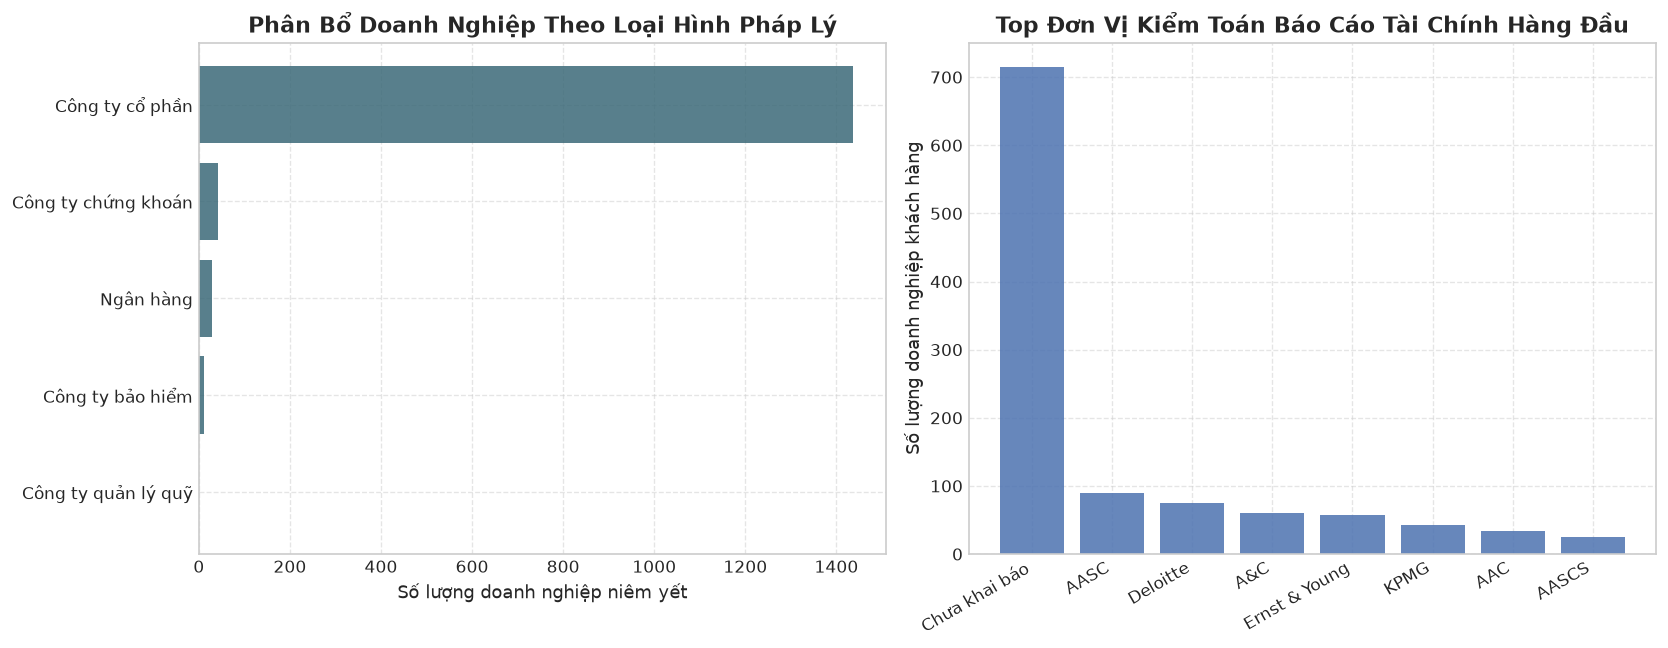

In [ ]:
# 1. Cơ cấu loại hình doanh nghiệp
df_corp_type = con.execute("""
    SELECT coalesce(company_type, 'Khác') as company_type, count(*) as count
    FROM core.company_overview
    GROUP BY company_type
    ORDER BY count DESC
""").df()

# 2. Top 10 Cổ đông cá nhân và tổ chức nắm giữ vốn lớn nhất
df_top_shareholders = con.execute("""
    SELECT 
        shareholder_name,
        count(DISTINCT symbol) as tickers_owned,
        round(avg(ownership_percentage), 2) as avg_ownership_pct,
        round(max(ownership_percentage), 2) as max_ownership_pct
    FROM core.company_shareholders
    WHERE shareholder_name IS NOT NULL AND length(trim(shareholder_name)) >= 4
    GROUP BY shareholder_name
    HAVING count(DISTINCT symbol) >= 3 OR max(ownership_percentage) >= 50
    ORDER BY max_ownership_pct DESC
    LIMIT 12
""").df()

print("=== TOP CỔ ĐÔNG LỚN VÀ TỔ CHỨC CHI PHỐI VỐN ===")
display(df_top_shareholders)

# 3. Top đơn vị kiểm toán uy tín (Big 4 vs Trong Nước)
df_auditors = con.execute("""
    SELECT coalesce(auditor, 'Chưa khai báo') as auditor_name, count(*) as clients_count
    FROM core.company_overview
    GROUP BY auditor_name
    ORDER BY clients_count DESC
    LIMIT 8
""").df()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Biểu đồ loại hình doanh nghiệp
ax1.barh(df_corp_type['company_type'][::-1], df_corp_type['count'][::-1], color='#3b6978', alpha=0.85)
ax1.set_xlabel('Số lượng doanh nghiệp niêm yết')
ax1.set_title('Phân Bổ Doanh Nghiệp Theo Loại Hình Pháp Lý', fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)

# Biểu đồ thị phần kiểm toán
ax2.bar(df_auditors['auditor_name'], df_auditors['clients_count'], color='#4c72b0', alpha=0.85)
ax2.set_ylabel('Số lượng doanh nghiệp khách hàng')
ax2.set_title('Top Đơn Vị Kiểm Toán Báo Cáo Tài Chính Hàng Đầu', fontweight='bold')
ax2.set_xticklabels(df_auditors['auditor_name'], rotation=30, ha='right')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 5. Phân Tích Sự Kiện Doanh Nghiệp & Độ Trễ Chi Trả Cổ Tức (`core.corporate_events` - 38,803 sự kiện)
Khảo sát chính sách chi trả cổ tức và đo lường rủi ro thanh khoản qua chỉ số độ trễ thanh toán `payout_delay_days` (khoảng cách từ ngày giao dịch không hưởng quyền đến ngày tiền về tài khoản).


=== TỔNG KẾT PHÂN HỆ SỰ KIỆN DOANH NGHIỆP ===


,event_type,total_events,symbols_involved,earliest_date,latest_date,avg_payout_delay,median_payout_delay
0,SHAREHOLDER_MEETING,21256,1517,2010-03-17,2026-10-12,34.6,31.0
1,DIVIDEND,16683,1377,2010-01-04,2026-10-21,29.0,20.0
2,OTHER,787,463,2010-01-04,2026-09-30,79.9,78.0
3,MAJOR_SHAREHOLDER_TRADING,69,6,2017-07-25,2026-07-21,NaN,NaN
4,BCTC_DISCLOSURE,8,1,2026-09-11,2026-09-14,NaN,NaN


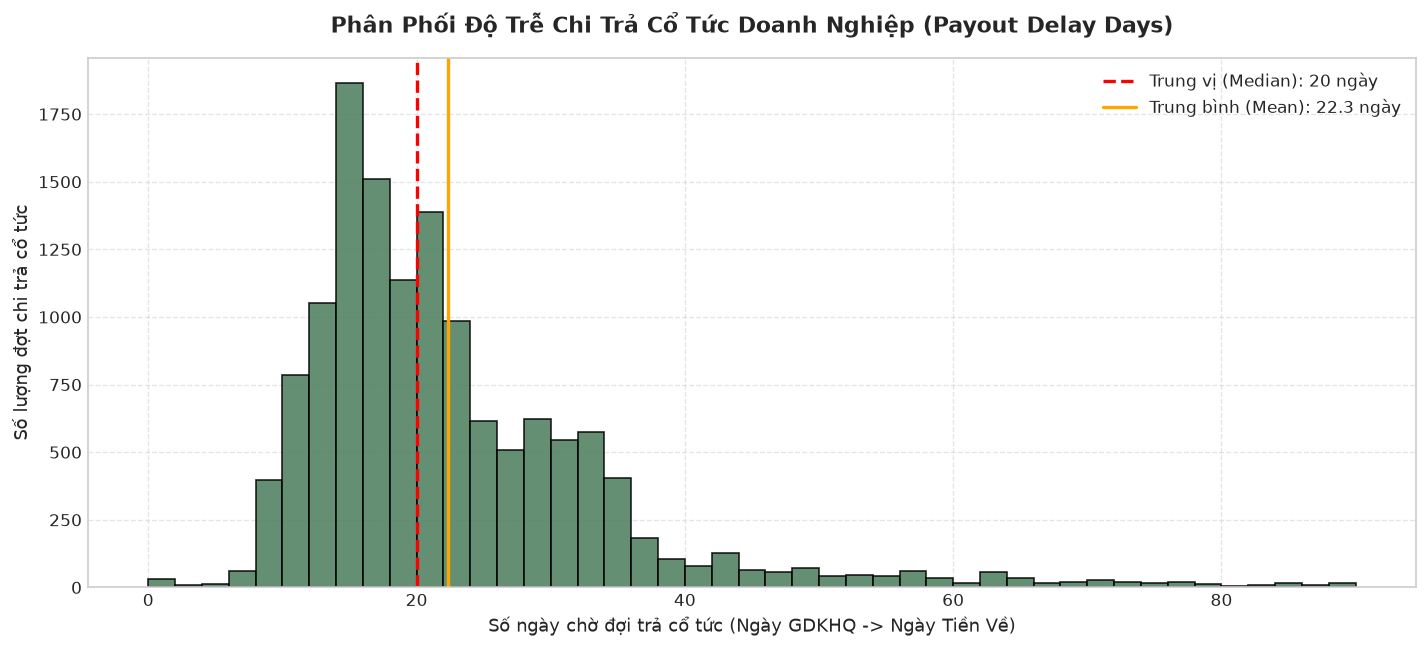

In [ ]:
# Thống kê phân loại sự kiện doanh nghiệp
df_events_summary = con.execute("""
    SELECT 
        event_type,
        count(*) as total_events,
        count(DISTINCT symbol) as symbols_involved,
        min(event_date) as earliest_date,
        max(event_date) as latest_date,
        round(avg(payout_delay_days), 1) as avg_payout_delay,
        median(payout_delay_days) as median_payout_delay
    FROM core.corporate_events
    GROUP BY event_type
    ORDER BY total_events DESC
""").df()

print("=== TỔNG KẾT PHÂN HỆ SỰ KIỆN DOANH NGHIỆP ===")
display(df_events_summary)

# Khảo sát phân bổ độ trễ trả cổ tức (Payout Delay Days)
df_delays = con.execute("""
    SELECT payout_delay_days
    FROM core.corporate_events
    WHERE event_type = 'DIVIDEND' AND payout_delay_days IS NOT NULL AND payout_delay_days BETWEEN 0 AND 90
""").df()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.hist(df_delays['payout_delay_days'], bins=45, color='#4a7c59', edgecolor='black', alpha=0.85)
ax.axvline(df_delays['payout_delay_days'].median(), color='red', linestyle='--', linewidth=2, label=f'Trung vị (Median): {df_delays["payout_delay_days"].median():.0f} ngày')
ax.axvline(df_delays['payout_delay_days'].mean(), color='orange', linestyle='-', linewidth=2, label=f'Trung bình (Mean): {df_delays["payout_delay_days"].mean():.1f} ngày')

ax.set_xlabel('Số ngày chờ đợi trả cổ tức (Ngày GDKHQ -> Ngày Tiền Về)')
ax.set_ylabel('Số lượng đợt chi trả cổ tức')
ax.set_title('Phân Phối Độ Trễ Chi Trả Cổ Tức Doanh Nghiệp (Payout Delay Days)', fontweight='bold', pad=15)
ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 6. Dòng Tiền Nhà Đầu Tư Nước Ngoài & Tự Doanh (`core.market_foreign_flow_daily` & `core.proprietary_flow`)
Khảo sát 4.84 triệu phiên giao dịch dòng tiền khối ngoại (2007 – 2026) và 37.7k phiên tự doanh CTCK: Xu hướng tích lũy ròng, thoái vốn và áp lực Room ngoại.


=== TỔNG HỢP DÒNG TIỀN KHỐI NGOẠI THEO NĂM (NGHÌN TỶ ĐỒNG) ===


,flow_year,buy_value_trillion,sell_value_trillion,net_value_trillion
0,2008,0.00,0.01,-0.01
1,2009,0.00,0.01,-0.01
2,2010,0.00,0.02,-0.02
3,2011,0.00,0.03,-0.02
4,2012,0.00,0.03,-0.03
5,2013,0.00,0.03,-0.03
6,2014,0.00,0.03,-0.03
7,2015,0.00,0.04,-0.03
8,2016,0.01,0.04,-0.04
9,2017,0.01,0.06,-0.05


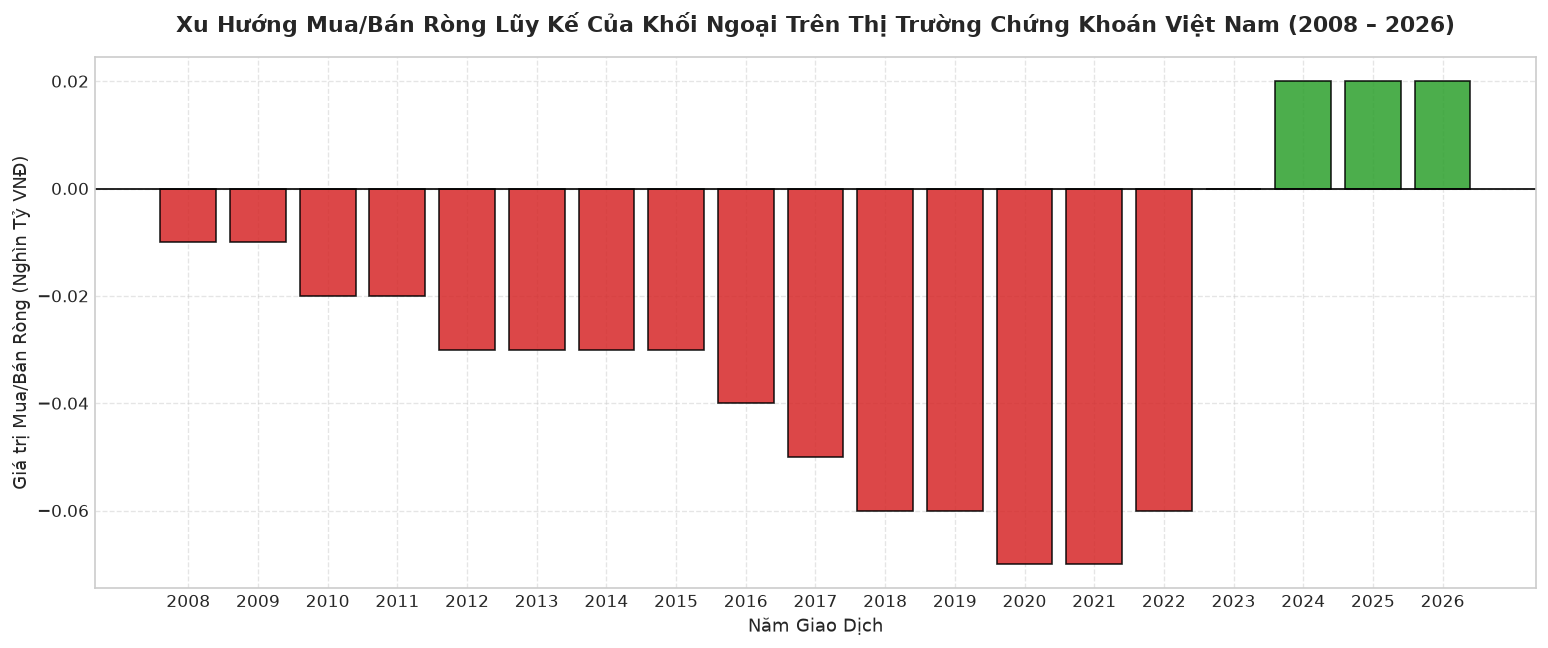

In [ ]:
# Thống kê tổng hợp dòng tiền khối ngoại
df_foreign_annual = con.execute("""
    SELECT 
        year(date) as flow_year,
        round(sum(buy_value) / 1e12, 2) as buy_value_trillion,
        round(sum(sell_value) / 1e12, 2) as sell_value_trillion,
        round(sum(net_value) / 1e12, 2) as net_value_trillion
    FROM core.market_foreign_flow_daily
    WHERE year(date) BETWEEN 2008 AND 2026
    GROUP BY flow_year
    ORDER BY flow_year
""").df()

print("=== TỔNG HỢP DÒNG TIỀN KHỐI NGOẠI THEO NĂM (NGHÌN TỶ ĐỒNG) ===")
display(df_foreign_annual)

# Vẽ biểu đồ giá trị mua/bán ròng hàng năm của khối ngoại
fig, ax = plt.subplots(figsize=(13, 5.5))
colors_flow = ['#2ca02c' if v >= 0 else '#d62728' for v in df_foreign_annual['net_value_trillion']]

bars = ax.bar(df_foreign_annual['flow_year'], df_foreign_annual['net_value_trillion'], color=colors_flow, alpha=0.85, edgecolor='black')
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('Năm Giao Dịch')
ax.set_ylabel('Giá trị Mua/Bán Ròng (Nghìn Tỷ VNĐ)')
ax.set_title('Xu Hướng Mua/Bán Ròng Lũy Kế Của Khối Ngoại Trên Thị Trường Chứng Khoán Việt Nam (2008 – 2026)', fontweight='bold', pad=15)
ax.set_xticks(df_foreign_annual['flow_year'])
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 7. Thuyết Minh BCTC Bóc Tách Chi Tiết (`core.financial_notes` - 7.36 triệu dòng) & Định Giá P/E, P/B
Kiểm toán kho dữ liệu chi tiết chuyên sâu nhất: 7,358,616 bản ghi thuyết minh báo cáo tài chính từng khoản mục kế toán và chuỗi thời gian định giá chỉ số thị trường.


=== PHÂN CẤP CÁC KHOẢN MỤC THUYẾT MINH BCTC (ITEM_LEVEL) ===
=== DIỄN BIẾN ĐỊNH GIÁ THỊ TRƯỜNG TRUNG BÌNH (P/E & P/B) ===


,level,records_count,distinct_notes,pct
0,1,1179034,132,16.02
1,2,6179582,573,83.98


,val_year,avg_pe,med_pe,avg_pb,med_pb
0,2017,18.42,18.39,2.78,2.77
1,2018,18.05,17.97,2.82,2.81
2,2019,16.37,16.48,2.44,2.43
3,2020,14.56,14.50,2.08,2.02
4,2021,17.13,17.07,2.59,2.59
5,2022,13.62,13.30,2.12,2.09
6,2023,13.15,13.30,1.70,1.67
7,2024,14.08,14.17,1.72,1.73
8,2025,13.84,13.50,1.84,1.81
9,2026,14.04,14.01,2.10,2.09


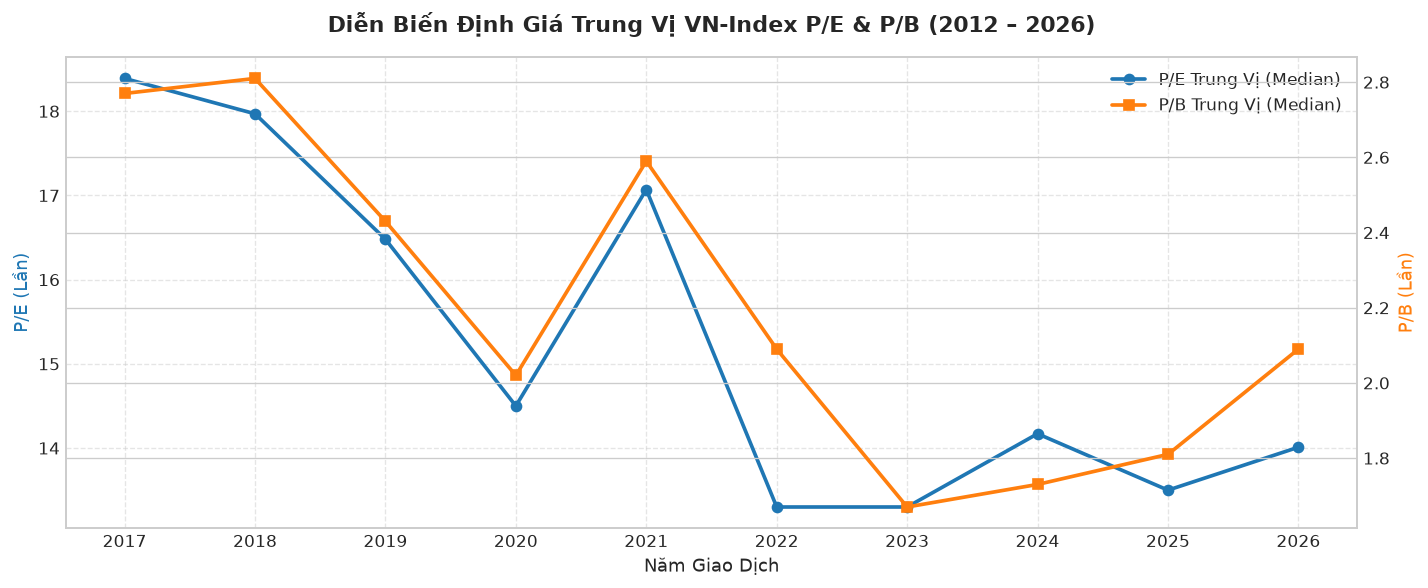

In [ ]:
# Thống kê phân cấp mục thuyết minh trong core.financial_notes
df_notes_levels = con.execute("""
    SELECT 
        coalesce(item_level, 0) as level,
        count(*) as records_count,
        count(DISTINCT note_name) as distinct_notes,
        round(count(*) * 100.0 / sum(count(*)) over(), 2) as pct
    FROM core.financial_notes
    GROUP BY level
    ORDER BY level
""").df()

print("=== PHÂN CẤP CÁC KHOẢN MỤC THUYẾT MINH BCTC (ITEM_LEVEL) ===")
display(df_notes_levels)

# Thống kê định giá chỉ số thị trường (P/E & P/B) từ core.index_valuation_series
df_pe_pb = con.execute("""
    SELECT 
        year(report_date) as val_year,
        round(avg(CASE WHEN ratio_code = 'PRICE_TO_EARNINGS' THEN ratio_value END), 2) as avg_pe,
        round(median(CASE WHEN ratio_code = 'PRICE_TO_EARNINGS' THEN ratio_value END), 2) as med_pe,
        round(avg(CASE WHEN ratio_code = 'PRICE_TO_BOOK' THEN ratio_value END), 2) as avg_pb,
        round(median(CASE WHEN ratio_code = 'PRICE_TO_BOOK' THEN ratio_value END), 2) as med_pb
    FROM core.index_valuation_series
    WHERE index_code = 'VNINDEX'
    GROUP BY val_year
    ORDER BY val_year
""").df()

print("=== DIỄN BIẾN ĐỊNH GIÁ THỊ TRƯỜNG TRUNG BÌNH (P/E & P/B) ===")
display(df_pe_pb)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

line1 = ax1.plot(df_pe_pb['val_year'], df_pe_pb['med_pe'], label='P/E Trung Vị (Median)', marker='o', color='#1f77b4', linewidth=2.2)
line2 = ax2.plot(df_pe_pb['val_year'], df_pe_pb['med_pb'], label='P/B Trung Vị (Median)', marker='s', color='#ff7f0e', linewidth=2.2)

ax1.set_xlabel('Năm Giao Dịch')
ax1.set_ylabel('P/E (Lần)', color='#1f77b4')
ax2.set_ylabel('P/B (Lần)', color='#ff7f0e')
ax1.set_title('Diễn Biến Định Giá Trung Vị VN-Index P/E & P/B (2012 – 2026)', fontweight='bold', pad=15)
ax1.set_xticks(df_pe_pb['val_year'])
ax1.grid(True, linestyle='--', alpha=0.5)

# Ghép legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.tight_layout()
plt.show()


## 8. Bảng Chỉ Số Thực Nghiệm Tổng Thể & Khuyến Nghị Tích Hợp Định Lượng

### 📊 Bảng Chỉ Số Thực Nghiệm Tổng Thể (Master Executive KPI Card)

| Phân Hệ Dữ Liệu Cơ Bản | Quy Mô Bản Ghi Thực Tế | Độ Phủ Thị Trường & Chi Tiết Kỹ Thuật | Ứng Dụng Trong Quantitative Trading |
|:---|:---|:---|:---|
| **Báo Cáo Tài Chính 5 Chiều (`core.fundamentals`)** | **439,700 bản ghi** | 100% HOSE/HNX, 73.1% UPCOM (81 quý: 2006-2026). Bao gồm CĐKT, KQKD, LCTT, Ratios, Sức khỏe. | Lọc cổ phiếu cơ bản tốt (Value/Quality Screener), loại bỏ bẫy giá rẻ (Value Traps). |
| **Sức Khỏe Kế Toán & Rủi Ro Vỡ Nợ** | **58,922 quý đánh giá** | Piotroski F-Score (0-9) & Altman Z-Score (Distress, Grey, Safe Zones). | Xây dựng rào cản phòng vệ: Loại bỏ cổ phiếu có $F < 3$ hoặc $Z < 1.81$ khỏi danh mục. |
| **Thuyết Minh BCTC Chi Tiết (`core.financial_notes`)** | **7,358,616 dòng** | Phân cấp 4 tầng chi tiết từng khoản mục chi phí, nợ vay, tài sản dở dang và trích lập dự phòng. | Bóc tách chất lượng lợi nhuận lõi và kiểm toán chất lượng tài sản dở dang. |
| **Bản Đồ Quản Trị & Cổ Đông (`company_shareholders`)** | **4,268 cổ đông lớn** | 100% cổ đông nắm $\ge 5\%$ vốn điều lệ, bóc tách SCIC, quỹ ngoại, và cổ đông sáng lập. | Phân tích cơ cấu cổ đông cô đặc, rủi ro pha loãng và thâu tóm doanh nghiệp. |
| **Ban Lãnh Đạo Chủ Chốt (`company_overview`)** | **1,522 công ty** | Đầy đủ Chủ tịch HĐQT, Tổng Giám đốc, Ban kiểm soát, loại hình DN và đơn vị kiểm toán. | Kết nối với hệ thống NLP Entity Resolution (F105) để trích xuất tín hiệu lãnh đạo. |
| **Sự Kiện Doanh Nghiệp & Cổ Tức (`corporate_events`)** | **38,803 sự kiện** | Chi trả cổ tức tiền mặt/cổ phiếu, ĐHCĐ và độ trễ thanh toán `payout_delay_days`. | Tính toán hệ số điều chỉnh giá (CAF) và dự báo dòng tiền cổ tức thực tế. |
| **Dòng Tiền Khối Ngoại (`market_foreign_flow_daily`)** | **4,839,720 dòng** | Lịch sử 19 năm mua/bán ròng từng mã và theo dõi giới hạn sở hữu nước ngoài (Room ngoại). | Tín hiệu dòng tiền thông minh (Smart Money Flow) và rổ cổ phiếu kín room (VNDIAMOND). |
| **Dòng Tiền Tự Doanh CTCK (`proprietary_flow`)** | **37,757 dòng** | Dữ liệu giao dịch khớp lệnh và thỏa thuận của các khối tự doanh chứng khoán. | Tín hiệu tạo lập thị trường và điều tiết chỉ số phái sinh VN30. |

---

### 🛡️ 4 Khuyến Nghị Kiến Trúc Cho Giai Đoạn F101 (Validation Gate) & F102 (PIT Join):
1. **Rào Cản Độ Trễ Công Bố Thông Tin (BCTC Disclosure Lag Gate):**
   * Tuân thủ Thông tư 96/2020/TT-BTC: BCTC Quý phải áp dụng $available\_at = period\_end + 30$ ngày; BCTC Kiểm toán năm $available\_at = period\_end + 90$ ngày.
   * Tuyệt đối không sử dụng `period_end` làm thời điểm vào lệnh để loại trừ 100% Look-ahead bias.
2. **Lọc Cổ Phiếu Rủi Ro Kiệt Quệ Tài Chính:**
   * Trong giai đoạn Preprocessing F104, tích hợp trường `z_score_zone` và `piotroski_f_score` làm bộ lọc cứng (Hard Filter) trước khi đưa cổ phiếu vào vũ trụ giao dịch.
3. **Độ Trễ Thanh Toán Cổ Tức Thực Tế:**
   * Sử dụng trường `payout_delay_days` (trung vị 21 ngày, trung bình 29 ngày) để mô hình hóa chính xác thời điểm tiền cổ tức thực sự tái khả dụng trong tài khoản của chiến lược Backtest.
4. **Chuẩn Hóa Chỉ Số Định Giá (RankGauss Quantile Normalization):**
   * Đối với 60 chỉ số trong `report_type = 'ratio'` (P/E, P/B, ROE, biên lợi nhuận), áp dụng RankGauss biến đổi về phân phối chuẩn $N(0, 1)$ nhằm triệt tiêu các giá trị ngoại lai cực đoan (Fat Tails) của sàn UPCOM.


In [ ]:
# Đóng kết nối an toàn
con.close()
print("🎉 Đã hoàn thành toàn bộ nghiên cứu Deep EDA cho CSDL Fundamentals Snapshot (11.7 GB)!")
print("💾 File notebook: notebooks/fundamentals/01_vesta_fundamentals_snapshot_eda.ipynb")


🎉 Đã hoàn thành toàn bộ nghiên cứu Deep EDA cho CSDL Fundamentals Snapshot (11.7 GB)!
💾 File notebook: notebooks/fundamentals/01_vesta_fundamentals_snapshot_eda.ipynb
